In [111]:
import gdown
import pandas as pd

gdown.download('https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head(10)

Downloading...
From: https://bit.ly/3pK7iuu
To: c:\data\ns_book7.csv
100%|██████████| 53.8M/53.8M [00:12<00:00, 4.34MB/s]


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19
5,6,처음 읽는 음식의 세계사,"미야자키 마사카츠 지음, 한세희 옮김",탐나는책,2021,9791189550370,NaN,NaN,NaN,NaN,1,0,2021-03-19
6,7,아르센 벵거 자서전 My Life in Red and White,"아르센 벵거 지음, 이성모 옮김",한즈미디어(한스미디어),2021,9791160075793,NaN,NaN,NaN,NaN,1,0,2021-03-19
7,8,쓰고 달콤한 직업,천운영 지음,마음산책,2021,9788960906679,NaN,NaN,NaN,NaN,1,0,2021-03-19
8,9,일잘러의 노션 100% 활용법,제레미 강 지음,위키북스,2021,9791158392512,NaN,NaN,NaN,NaN,1,0,2021-03-19
9,10,타이난 골목 노포 산책,"천구이팡 지음, 심혜경 외 옮김",페이퍼스토리,2021,9788998690557,NaN,NaN,NaN,NaN,1,0,2021-03-19


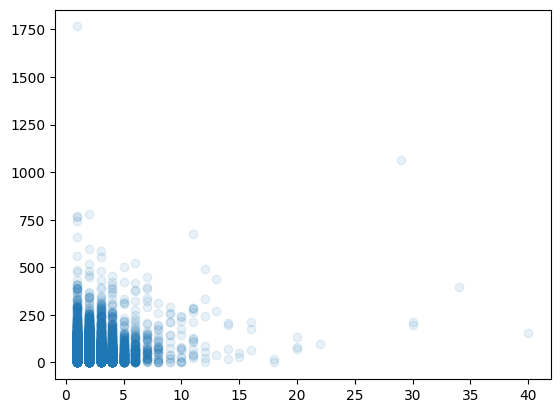

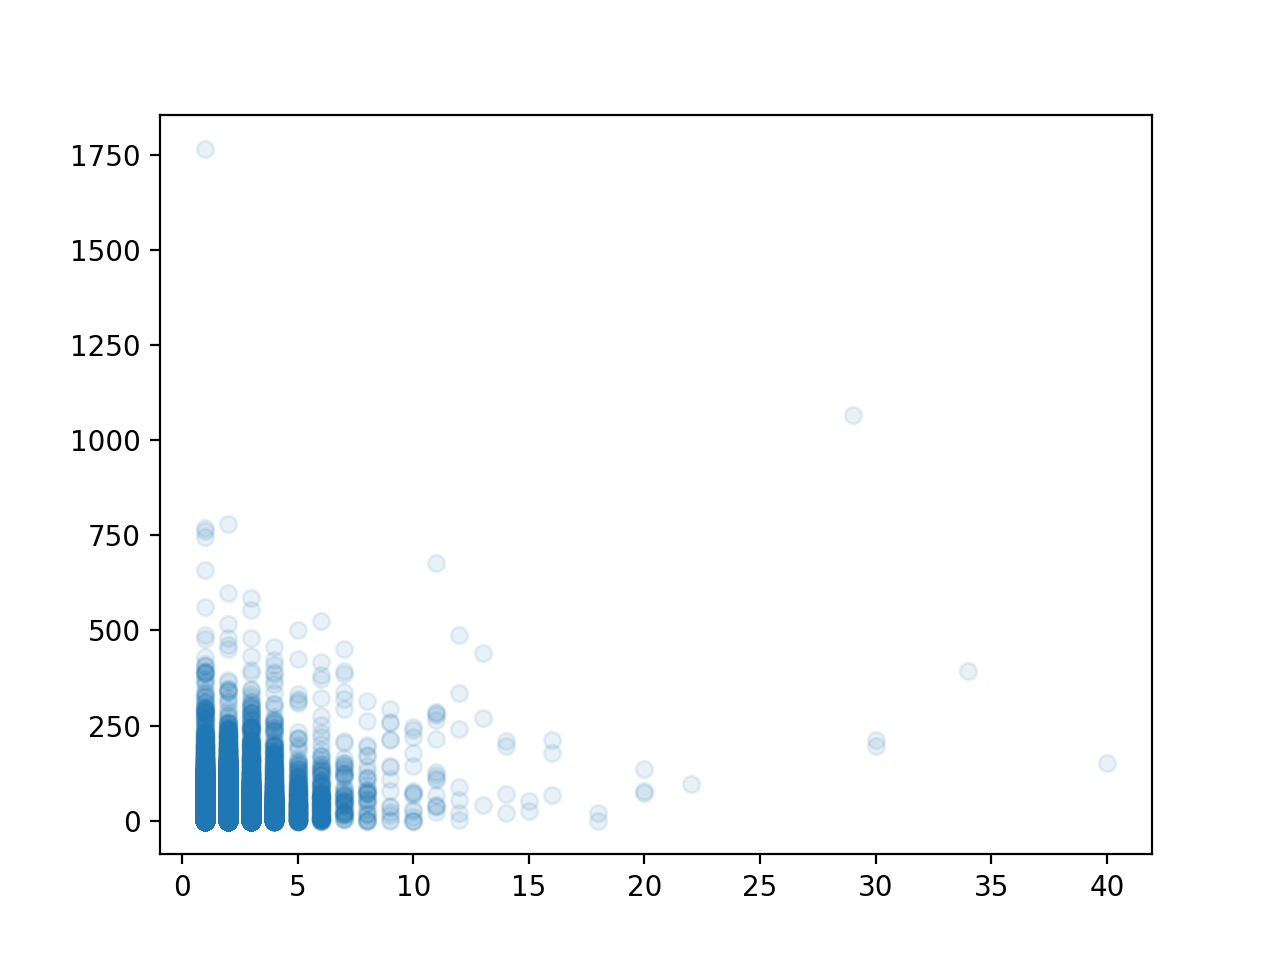

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}
plt.figure(dpi=200)
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

## 1) 먼저 상황: 코랩/주피터는 그래프를 “이미지로 만들어서” 화면에 붙인다

`plt.show()`를 하면, 화면에 그래프가 바로 그려지는 것처럼 보이지만 실제로는:

1. Matplotlib이 그래프를 **PNG 같은 이미지**로 만든다
2. 코랩(InlineBackend)이 그 이미지를 노트북 셀 아래에 **붙여서 보여준다**

즉, “노트북 출력”은 일종의 **자동 저장 + 표시** 과정이야.

---

## 2) 문제: “tight(딱 맞게 자르기)”가 켜져 있으면 크기가 바뀔 수 있다

코랩/주피터는 어떤 설정에서는 그래프를 화면에 붙일 때
그림의 바깥 여백을 **자동으로 잘라내서(tight)** 딱 붙게 만들기도 해.

이게 뭐가 문제냐면:

* 원래는 그림 전체 캔버스가 예를 들어 **900×600 픽셀**인데
* “tight”로 자르면 바깥 여백이 잘려서 **860×580**처럼 **픽셀 크기가 달라질 수 있어**

그래서 교과서는 “원래 의도한 크기(예: 900×600)를 유지하려면 잘라내지 말아라”라고 하는 거야.

---

## 3) 그래서 `bbox_inches=None`을 준다

`bbox_inches`는 “그림을 저장/출력할 때 얼마나 잘라낼지”를 정하는 옵션이야.

* `bbox_inches="tight"` : 내용만 남기고 **여백을 잘라냄** (크기 바뀔 수 있음)
* `bbox_inches=None` : **자르지 않음** (원래 캔버스 크기 유지)

교과서가 `bbox_inches=None`을 쓰라고 한 이유는:

✅ **출력되는 이미지가 잘려서 크기가 달라지는 걸 막기 위해서**야.

---

## 4) 그럼 이 줄은 정확히 뭔 뜻이야?

### 코드

```python
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
```

### 해체 설명

* `%config`
  → “주피터/코랩의 설정을 바꿀게”라는 뜻 (파이썬 문법이 아니라 노트북 명령어)

* `InlineBackend`
  → 노트북이 그래프를 “이미지로 만들어서 화면에 붙이는 기능” 담당

* `print_figure_kwargs`
  → 그 이미지를 만들 때 Matplotlib에 넘겨주는 “추가 옵션들”
  (여기서 `kwargs`는 어려운 말로 “옵션 묶음” 정도로 생각하면 돼)

* `= {'bbox_inches': None}`
  → “그래프를 화면에 출력할 때는 `bbox_inches=None` 옵션을 적용해라”
  즉, **자르지 말고 원래 크기대로 출력해라**

---

## 5) 왜 책에선 “타이트 레이아웃 끄기”라고 표현했을까?

엄밀히 말하면 이건 `tight_layout()`(레이아웃 정리)랑 완전히 같은 개념은 아니고,

**“tight하게 잘라내기(crop)”를 끈다**에 더 가까워.

하지만 초급 교재에서는 둘을 뭉뚱그려 “타이트”라고 부르는 경우가 있어.

---

## 6) 너는 “이걸 해도 안 해도 900×600이 나오던데?”

그럴 수 있어. 이유는 보통 둘 중 하나야:

1. 네 환경에서는 원래부터 “tight 자르기”가 기본이 아니었음
2. 산점도처럼 단순한 그림은 잘라낼 여백이 거의 없어서 결과가 같았음

차이는 보통 **제목/축 라벨/범례**가 커서 여백이 필요할 때 더 잘 나타나.

---

## 7) 한 줄 요약

`%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}`
= **노트북이 그래프를 화면에 이미지로 붙일 때, 자동으로 잘라내지 말고(크기 바꾸지 말고) 원래 크기대로 보여줘.**

---

원하면 “차이가 진짜 생기는” 예시를 아주 짧게 만들어서,
`bbox_inches="tight"`일 때랑 `None`일 때 **픽셀이 어떻게 달라지는지** 눈으로 확인하는 코드도 만들어줄게.


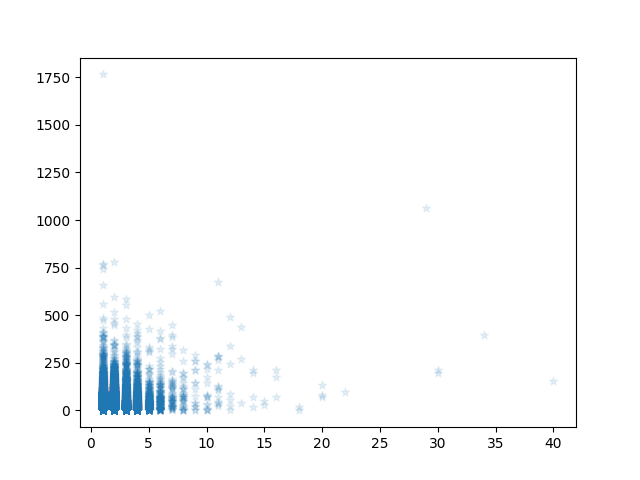

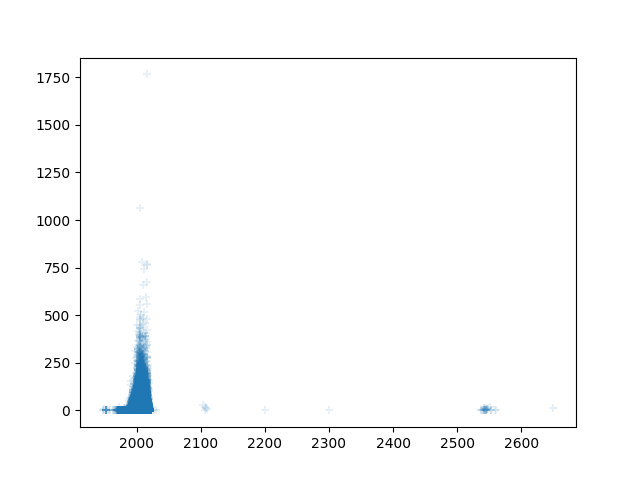

[6.4, 4.8]
[9.0, 6.0]


In [ ]:
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.dpi']

plt.rcParams['scatter.marker'] = '*'
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
#Figure는 matplotlib에서 만들어진 그래프 개별하나하나의 요소들을 관리, rcParams는 맷플롯립에서 그래프를 만드는 기본값을 관리.
plt.show()

plt.scatter(ns_book7['발행년도'], ns_book7['대출건수'], alpha=0.1, marker='+')
plt.show()

print(plt.rcParams['figure.figsize'])
plt.rcParams['figure.figsize'] = (9, 6)
print(plt.rcParams['figure.figsize'])



In [121]:
ns_book7['등록일자'] = ns_book7['등록일자'].astype('string').replace({r'^(\d{4})-(\d{2})-(\d{2})$': r'\1'}, regex=True)
na_ray = ~ ns_book7['등록일자'].astype('string').str.fullmatch(r'\d{4}', na=False)
ns_book7['등록일자'] = ns_book7['등록일자'].astype('int64')

ns_book7 = ns_book7[ns_book7['발행년도'] <= 2026]

ns_book7 = ns_book7[ns_book7['발행년도'] <= ns_book7['등록일자']]

ns_book7 = ns_book7[ns_book7['등록일자']>=2002]



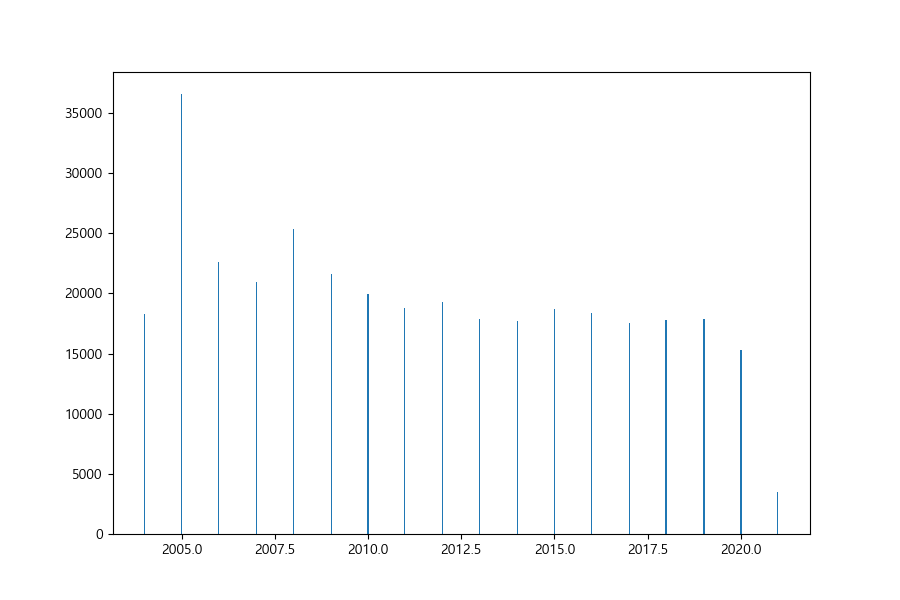

int64


In [122]:
ns_book7.head()
ns_book7 = ns_book7[ns_book7['등록일자']>=2002]
plt.hist(ns_book7['등록일자'], bins=500)
plt.show()

print(ns_book7['등록일자'].dtype)


C:\Users\박중현\AppData\Local\Temp\ipykernel_396\384208733.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


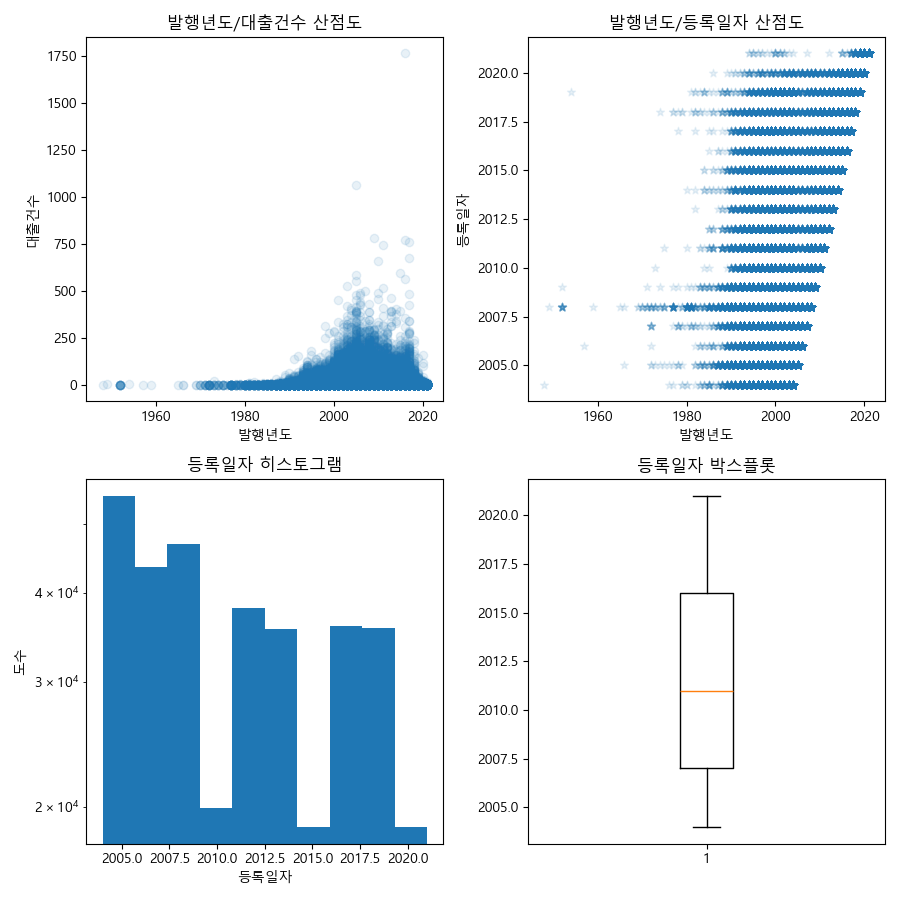

In [123]:

#서브플롯으로 구성된--axes클래스의-- 피겨 객체와 axes 객체 배열들을 만들고 행 2개 열 2개의 그래프 만들기(스, 스, 히스토, 박스플롯)
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axs = plt.subplots(2, 2, figsize=(9, 9))

axs[0, 0].scatter(ns_book7['발행년도'], ns_book7['대출건수'], alpha=0.1, marker='o')
axs[0, 0].set_xlabel('발행년도')
axs[0, 0].set_ylabel('대출건수')
# axs[0, 0].set_xscale('log')
axs[0, 0].set_title('발행년도/대출건수 산점도')

axs[0, 1].scatter(ns_book7['발행년도'], ns_book7['등록일자'], alpha=0.1, marker='*')
axs[0, 1].set_title('발행년도/등록일자 산점도')
axs[0, 1].set_xlabel('발행년도')
axs[0, 1].set_ylabel('등록일자')
# axs[0, 1].set_yscale('log')

axs[1, 0].hist(ns_book7['등록일자'])
axs[1, 0].set_title('등록일자 히스토그램')
axs[1, 0].set_xlabel('등록일자')
axs[1, 0].set_ylabel('도수')
axs[1, 0].set_yscale('log')

axs[1, 1].boxplot(ns_book7['등록일자'])
axs[1, 1].set_title('등록일자 박스플롯')


fig.tight_layout()

fig.show()